  Instalações de bibliotecas necessárias

In [2]:
!pip install shap

In [38]:
import os
import pandas as pd
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import mean_squared_error, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import shap

  Na literatura médica: Esse dataset usa um teste oficial chamado AQ-10 Adult (Autism Spectrum Quotient 10).Se você pesquisar no Google por "AQ-10 test pdf", foi usado para coletar esses dados.

  Que essas questões são A1_Score até A10_Score
  [AQ-10 test pdf](https://bibliotecadeinstrumentos.com.br/instrumentos/autism-spectrum-quotient-adult-aq-10__2d1938f9-565e-44b8-8dd9-52d34ece6bf4/pdf)

In [4]:
texto_das_perguntas = {
    'A1_Score': 'Percebe pequenos sons que os outros não notam?',
    'A2_Score': 'Tende a focar nos pequenos detalhes em vez do todo?',
    'A3_Score': 'Tem facilidade em fazer mais de uma coisa ao mesmo tempo?',
    'A4_Score': 'Percebe facilmente quando alguém está ficando entediado conversando com você?',
    'A5_Score': 'Tem facilidade em "ler nas entrelinhas" o que as pessoas dizem?',
    'A6_Score': 'Tem facilidade em descobrir as intenções das outras pessoas?',
    'A7_Score': 'Entende facilmente as intenções dos personagens em filmes ou livros?',
    'A8_Score': 'Gosta de colecionar informações sobre categorias (carros, plantas, etc.)?',
    'A9_Score': 'Sabe o que alguém está sentindo apenas olhando para o rosto da pessoa?',
    'A10_Score': 'Tem dificuldade em descobrir as intenções das pessoas?'
}

   Recuperando dados do dataset



In [5]:
path = kagglehub.dataset_download("stealthtechnologies/predict-autism-spectrum-disorder-asd")

csv_path=os.path.join(path,"Autism.csv")

df = pd.read_csv(csv_path)
df

100%|██████████| 7.30k/7.30k [00:00<00:00, 9.86MB/s]

Extracting files...


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,...,f,White-European,no,no,'United States',no,6,'18 and more',Self,NO
1,1,1,0,1,0,0,0,1,0,1,...,m,Latino,no,yes,Brazil,no,5,'18 and more',Self,NO
2,1,1,0,1,1,0,1,1,1,1,...,m,Latino,yes,yes,Spain,no,8,'18 and more',Parent,YES
3,1,1,0,1,0,0,1,1,0,1,...,f,White-European,no,yes,'United States',no,6,'18 and more',Self,NO
4,1,0,0,0,0,0,0,1,0,0,...,f,?,no,no,Egypt,no,2,'18 and more',?,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,0,1,0,1,1,0,1,1,1,1,...,f,White-European,no,no,Russia,no,7,'18 and more',Self,YES
700,1,0,0,0,0,0,0,1,0,1,...,m,Hispanic,no,no,Mexico,no,3,'18 and more',Parent,NO
701,1,0,1,1,1,0,1,1,0,1,...,f,?,no,no,Russia,no,7,'18 and more',?,YES
702,1,0,0,1,1,0,1,0,1,1,...,m,'South Asian',no,no,Pakistan,no,6,'18 and more',Self,NO


  Removendo dados irrelevantes

In [6]:
colunas_para_remover = ['age_desc', 'relation', 'ethnicity', 'jundice', 'contry_of_res', 'used_app_before', 'result']
df = df.drop(columns=colunas_para_remover, errors='ignore')
df

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,austim,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,26,f,no,NO
1,1,1,0,1,0,0,0,1,0,1,24,m,yes,NO
2,1,1,0,1,1,0,1,1,1,1,27,m,yes,YES
3,1,1,0,1,0,0,1,1,0,1,35,f,yes,NO
4,1,0,0,0,0,0,0,1,0,0,40,f,no,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,0,1,0,1,1,0,1,1,1,1,25,f,no,YES
700,1,0,0,0,0,0,0,1,0,1,34,m,no,NO
701,1,0,1,1,1,0,1,1,0,1,24,f,no,YES
702,1,0,0,1,1,0,1,0,1,1,35,m,no,NO


  Transformar dados em numéricos

In [7]:
encoder = LabelEncoder()
for coluna in df.select_dtypes(include=['object']).columns:
    df[coluna] = encoder.fit_transform(df[coluna])
df

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,austim,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,9,0,0,0
1,1,1,0,1,0,0,0,1,0,1,7,1,1,0
2,1,1,0,1,1,0,1,1,1,1,10,1,1,1
3,1,1,0,1,0,0,1,1,0,1,18,0,1,0
4,1,0,0,0,0,0,0,1,0,0,24,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,0,1,0,1,1,0,1,1,1,1,8,0,0,1
700,1,0,0,0,0,0,0,1,0,1,17,1,0,0
701,1,0,1,1,1,0,1,1,0,1,7,0,0,1
702,1,0,0,1,1,0,1,0,1,1,18,1,0,0


In [26]:
df.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'austim', 'Class/ASD'],
      dtype='object')

In [8]:
# Separandos as características (X) do alvo (Y - que a coluna "Class/ADS")
X = df.drop('Class/ASD', axis=1)
y = df['Class/ASD']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

  Criando o Modelo

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [10]:
# Técnica de Balanciamento
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {0: class_weights[0], 1: class_weights[1]}
class_weights

{0: np.float64(0.6865853658536586), 1: np.float64(1.8398692810457515)}

In [11]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(units=128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dropout(0.2))

model.add(tf.keras.layers.Dense(units=64, activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dropout(0.2))

model.add(tf.keras.layers.Dense(units=64, activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dropout(0.2))

model.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,297 (59.75 KB)

 Trainable params: 14,785 (57.75 KB)

 Non-trainable params: 512 (2.00 KB)

In [12]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

In [13]:
historyADS = model.fit(X_train, y_train, epochs=40, batch_size=32, class_weight=class_weights, validation_split=0.2)

Epoch 1/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 15s 59ms/step - accuracy: 0.6778 - loss: 0.5573 - val_accuracy: 0.8761 - val_loss: 0.5505
Epoch 2/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8400 - loss: 0.3188 - val_accuracy: 0.9381 - val_loss: 0.4615
Epoch 3/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.8933 - loss: 0.2104 - val_accuracy: 0.9469 - val_loss: 0.3883
Epoch 4/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8889 - loss: 0.2205 - val_accuracy: 0.9469 - val_loss: 0.3263
Epoch 5/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9289 - loss: 0.1696 - val_accuracy: 0.9646 - val_loss: 0.2642
Epoch 6/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9400 - loss: 0.1402 - val_accuracy: 0.9735 - val_loss: 0.2297
Epoch 7/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.9400 - loss: 0.1393 - val_accuracy: 0.9735 - val_loss: 0.1929
Epoch 8/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9556 - loss: 0.1378 - val_accuracy: 0.9735 - 

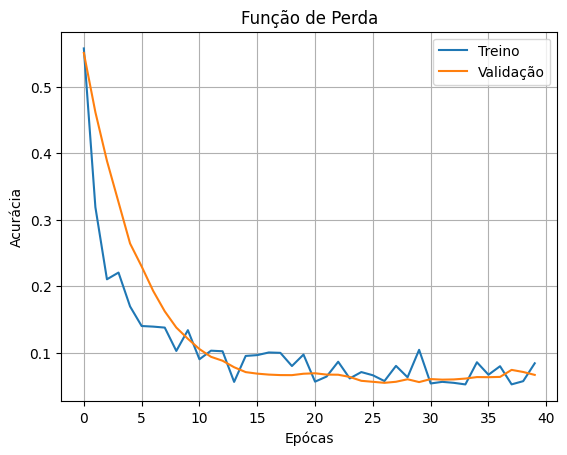

In [14]:
plt.plot(historyADS.history['loss'], label='Treino')
plt.plot(historyADS.history['val_loss'], label='Validação')
plt.title('Função de Perda')
plt.xlabel('Epócas')
plt.ylabel('Acurácia')
plt.legend(['Treino', 'Validação'])
plt.grid(True)
plt.savefig('loss_function.png', bbox_inches='tight', dpi=300)
plt.show()

In [15]:
model.save('model.keras')

In [16]:
model_carregado = tf.keras.models.load_model('model.keras')

In [17]:
output_proba = model.predict(X_test)

output_proba = output_proba.reshape(output_proba.shape[0])

output_pred = (output_proba > 0.5).astype(int)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


In [18]:
def model_predict(X_test):
    output_proba = model.predict(X_test)
    output_proba = output_proba.reshape(output_proba.shape[0])
    output_pred = (output_proba > 0.5).astype(int)
    return output_pred

In [19]:
print(classification_report(y_test, output_pred))

              precision    recall  f1-score   support

           0       0.99      0.96      0.98       105
           1       0.90      0.97      0.93        36

    accuracy                           0.96       141
   macro avg       0.94      0.97      0.95       141
weighted avg       0.97      0.96      0.96       141



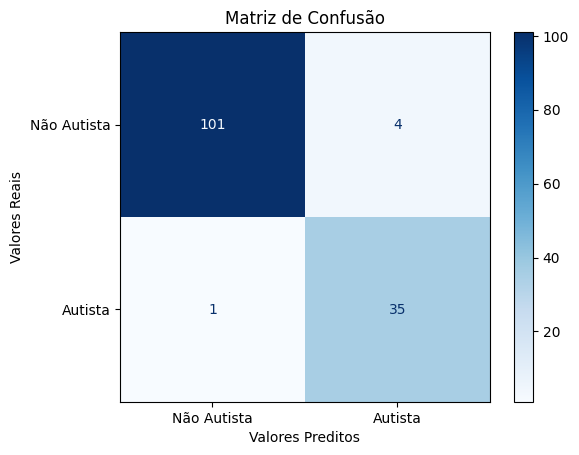

In [20]:
cm = confusion_matrix(y_test, output_pred)
cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não Autista', 'Autista'])
cmd.plot(cmap='Blues')
plt.title('Matriz de Confusão')
plt.xlabel('Valores Preditos')
plt.ylabel('Valores Reais')
plt.savefig('confusion_matrix.png', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
# SHAP

In [22]:
explainer = shap.KernelExplainer(model_predict, X_test[:10])
shap_values = explainer.shap_values(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


  0%|          | 0/141 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
649/649 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
649/649 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
649/649 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
649/649 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
649/649 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
649/649 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
649/649 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
649/649 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
649/649 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
649/649 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
649/649 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
649/649 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
649/649 ━━━━

In [25]:
shap_values.shape

(141, 13)

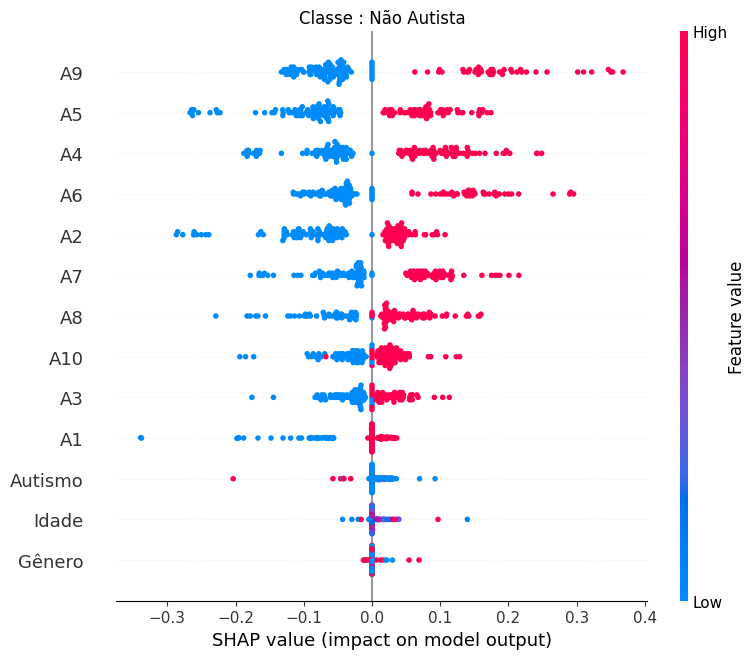

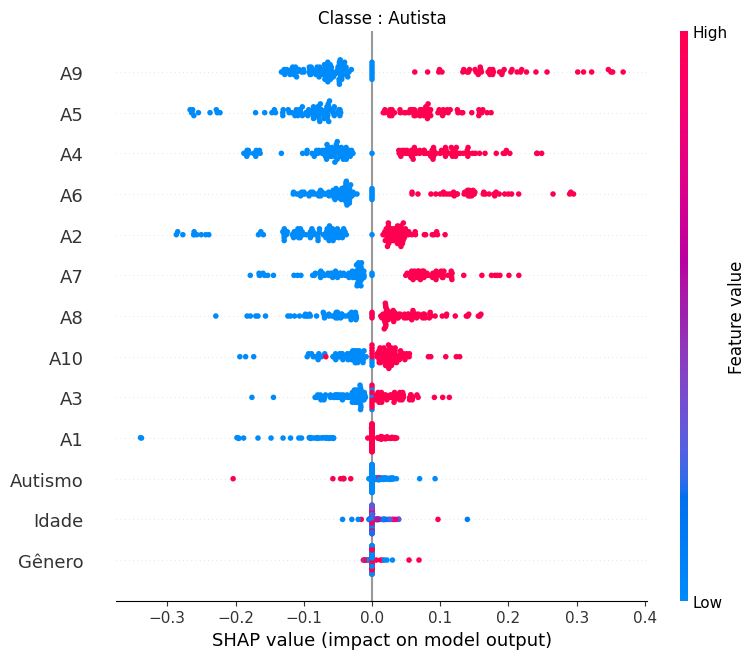

In [60]:
class_names = ['Não Autista', 'Autista']
nomes_portugues = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6',
       'A7', 'A8', 'A9', 'A10', 'Idade', 'Gênero',
       'Autismo']
for i, class_name in enumerate(class_names):
  plt.figure(figsize=(6, 3))
  plt.title(f'Classe : {class_name}')
  shap_valores_classe = shap_values[i]
  shap.summary_plot(shap_values, X_test, feature_names=nomes_portugues, class_names=class_names, show=False)
  plt.savefig(f'summary_plot_{class_name}.png', bbox_inches='tight', dpi=300)
  plt.show()

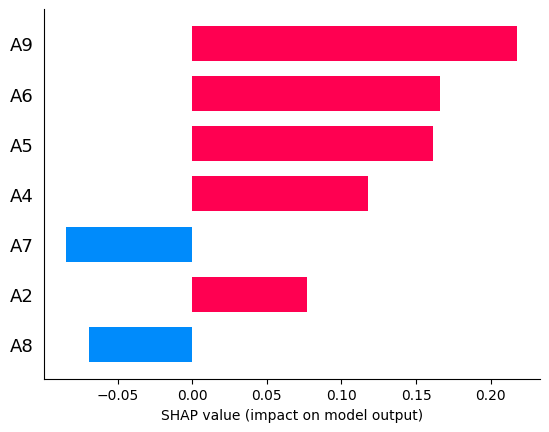

<Figure size 640x480 with 0 Axes>

In [61]:
shap.bar_plot(shap_values[0], feature_names=nomes_portugues)
plt.savefig(f'bar_plot_{class_name}.png', bbox_inches='tight', dpi=300)
plt.show()